In [1]:
import os
import sys
import h5py
from tqdm import tqdm
import matplotlib.pyplot as plt

import copy
import numpy as np
from astropy.cosmology import Planck18

PACKAGE_PARENT = '..'
SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.getcwd())))
sys.path.append(SCRIPT_DIR)

import gwfast.gwfastGlobals as glob
from gwfast.waveforms import IMRPhenomD
import lalsimulation as lalsim
import lal
from gwfast.signal import GWSignal
from gwfast.network import DetNet
from fisherTools import CovMatr, compute_localization_region, check_covariance, fixParams
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from scipy.interpolate import interp1d

TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
## 2L-shaped ET 15km + CE20
alldetectors = copy.deepcopy(glob.detectors)
detectors = {det: alldetectors[det] for det in ["ETSL", "ETMRL45d", "CE1Id"]}
detectors["ETSL"]["psd_path"] = os.path.join(glob.detPath, "ET_designs_comparison_paper/HFLF_cryo/ETLength15km.txt")
detectors["ETMRL45d"]["psd_path"] = os.path.join(glob.detPath, "ET_designs_comparison_paper/HFLF_cryo/ETLength15km.txt")
detectors["CE1Id"]["psd_path"] = os.path.join(glob.detPath, "ce_strain/cosmic_explorer_20km.txt")

In [3]:
Signals = {}

for d in detectors.keys():

    Signals[d] = GWSignal(IMRPhenomD(), 
                psd_path=detectors[d]['psd_path'],
                detector_shape = detectors[d]['shape'],
                det_lat= detectors[d]['lat'],
                det_long= detectors[d]['long'],
                det_xax= detectors[d]['xax'], 
                verbose=False, # so it does not print "compute derivatives etc..."
                useEarthMotion = False,
                fmin=3., # ET paper https://iopscience.iop.org/article/10.1088/0264-9381/27/19/194002/pdf
                IntTablePath=None) 
        
myNet = DetNet(Signals)      

In [4]:
import h5py

with h5py.File("../BBH_injections.h5", "r") as f:
    BBH_inj = {key: f[key][()] for key in f.keys()}

BBH_injections = { "Mc": BBH_inj["Mc"], "eta": BBH_inj["eta"], "chi1z": BBH_inj["chi1z"], "chi2z": BBH_inj["chi2z"],
                   "dL": BBH_inj["dL"], "theta": BBH_inj["theta"], "phi": BBH_inj["phi"], "iota": BBH_inj["iota"],
                  "psi": BBH_inj["psi"], "tcoal": BBH_inj["tcoal"], "Phicoal": BBH_inj["Phicoal"],  "z": BBH_inj["z"]}

print("# tot BBH injections:", len(BBH_injections["Mc"]))

# tot BBH injections: 87665


#### Uniform redshift bins are required to esimate the detection efficiency and detection rate

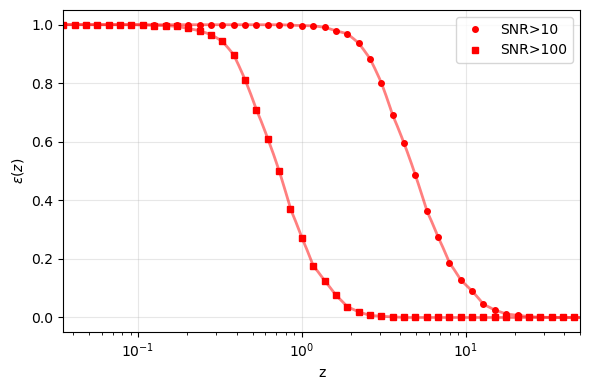

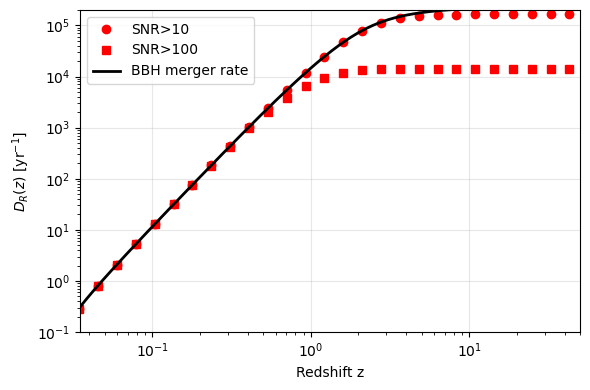

In [5]:
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315)
bins = np.logspace(np.log10(0.02), np.log10(50.0), 50) 
zmid = np.sqrt(bins[:-1] * bins[1:])
Ninj_bin = 1000

efficiency10 = np.zeros(len(zmid))
efficiency100 = np.zeros(len(zmid))
np.random.seed(7)
idx = np.random.choice(len(BBH_inj["Mc"]), Ninj_bin, replace=False)

for i in range(len(zmid)):
    zleft, zright = bins[i], bins[i+1]
    z_bin = np.random.uniform(zleft, zright, Ninj_bin)
    dL_bin = cosmo.luminosity_distance(z_bin).to(u.Gpc).value

    BBH_injections_bin = { "Mc": BBH_inj["Mc"][idx], "eta": BBH_inj["eta"][idx], "chi1z": BBH_inj["chi1z"][idx],
                           "chi2z": BBH_inj["chi2z"][idx], "dL": dL_bin, "theta": BBH_inj["theta"][idx], 
                           "phi": BBH_inj["phi"][idx], "iota": BBH_inj["iota"][idx],"psi": BBH_inj["psi"][idx],
                           "tcoal":  BBH_inj["tcoal"][idx], "Phicoal": BBH_inj["Phicoal"][idx], "z": z_bin}

    SNR = myNet.SNR(BBH_injections_bin)
    efficiency10[i] = np.mean(SNR >= 10)
    efficiency100[i] = np.mean(SNR >= 100)

efficiency10_z = interp1d(zmid, efficiency10, kind="linear", bounds_error=False, fill_value=0.0)
efficiency100_z = interp1d(zmid, efficiency100, kind="linear", bounds_error=False, fill_value=0.0)

plt.figure(figsize=(6,4))
plt.plot(zmid, efficiency10, "o", ms=4, color='r', label='SNR>10',)
plt.plot(zmid, efficiency100, "s", ms=4, color='r', label='SNR>100',)

z_xaxis = np.logspace(np.log10(0.02), np.log10(50.0), 500)
plt.plot(z_xaxis, efficiency10_z(z_xaxis), lw=2, alpha=0.5, color='r')
plt.plot(z_xaxis, efficiency100_z(z_xaxis), lw=2, alpha=0.5, color='r')
plt.xlim(0.035, 50)
plt.xscale("log")
plt.xlabel("z")
plt.ylabel(r"$\epsilon(z)$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


gamma = 2.7
kappa = 5.6
z_p = 1.9
R0_BBH = 22
z_int = np.logspace(np.log10(0.02), np.log10(50.0), 2000)
psi = (1 + z_int)**gamma / (1 + ((1 + z_int)/(1 + z_p))**kappa)

td_min = 20e6 * u.yr
td_max = 10e9 * u.yr
td_grid = np.logspace(np.log10(td_min.to(u.yr).value), np.log10(td_max.to(u.yr).value), 400)
P_td = 1.0 / td_grid
P_td /= np.trapezoid(P_td, td_grid)

z_tab = np.logspace(-4, 4, 5000)
t_tab = cosmo.age(z_tab).to(u.yr).value
z_of_t = interp1d(t_tab[::-1], z_tab[::-1], bounds_error=False, fill_value=z_tab[-1])

n_dot = np.zeros_like(z_int)

for i, z in enumerate(z_int):
    t_z = cosmo.age(z)
    t_f = t_z + td_grid * u.yr
    mask = t_f < cosmo.age(0)
    z_f = z_of_t(t_f[mask].to(u.yr).value)
    psi_f = (1 + z_f)**gamma / (1 + ((1 + z_f)/(1 + z_p))**kappa)
    n_dot[i] = np.trapezoid(psi_f * P_td[mask], td_grid[mask])

n_dot *= R0_BBH / n_dot[np.argmin(np.abs(z_int))]

dVc_dz = cosmo.differential_comoving_volume(z_int).to(u.Gpc**3 / u.sr).value * 4*np.pi
integrand = n_dot / (1 + z_int) * dVc_dz
merger_rate = np.cumsum(integrand * np.gradient(z_int))

integrand10 = efficiency10_z(z_int) * n_dot / (1 + z_int) * dVc_dz
det_rate10 = np.cumsum(integrand10 * np.gradient(z_int))
integrand100 = efficiency100_z(z_int) * n_dot / (1 + z_int) * dVc_dz
det_rate100 = np.cumsum(integrand100 * np.gradient(z_int))

plt.figure(figsize=(6,4))
plt.plot(z_int, det_rate10, marker="o", markevery=70, lw=2, linestyle='none', label='SNR>10', color='r')
plt.plot(z_int, det_rate100, marker="s", markevery=70, lw=2, linestyle='none', label='SNR>100', color='r')
plt.plot(z_int, merger_rate, lw=2, label='BBH merger rate', color='k')
plt.xlim(0.035, 50)
plt.ylim(0.1, 2e5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Redshift z")
plt.ylabel(r"$D_R(z)$ [yr$^{-1}$]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Save hdf5 file

In [6]:
outname = "B BBH_ET2L-CE20_det.h5"

with h5py.File(outname, "w") as f:

    eff = f.create_group("efficiency")
    eff.create_dataset("zmid", data=zmid)
    eff.create_dataset("efficiency10", data=efficiency10)
    eff.create_dataset("efficiency100", data=efficiency100)

    rate = f.create_group("rates")
    rate.create_dataset("z", data=z_int)
    rate.create_dataset("merger_rate", data=merger_rate)
    rate.create_dataset("det_rate10", data=det_rate10)
    rate.create_dataset("det_rate100", data=det_rate100)

    f.attrs["R0_BBH"] = R0_BBH
    f.attrs["gamma"] = gamma
    f.attrs["kappa"] = kappa
    f.attrs["z_p"] = z_p
    f.attrs["cosmology"] = "FlatLambdaCDM(H0=67.4, Om0=0.315)"


# IMBBH

# tot BBH injections: 3984


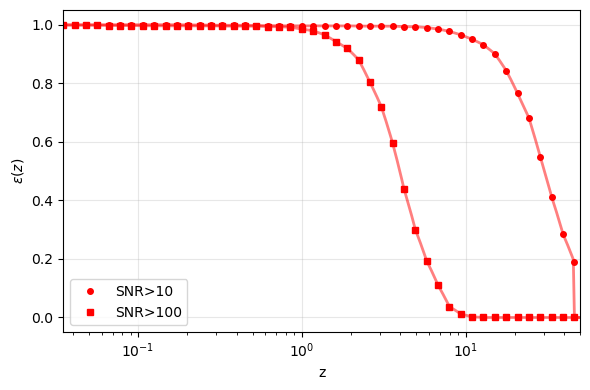

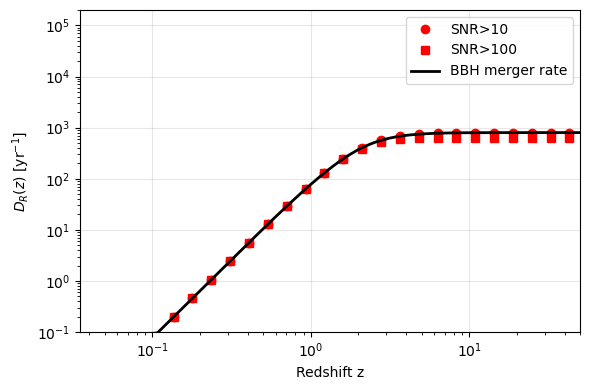

In [7]:
import h5py

with h5py.File("../IMBBH_injections.h5", "r") as f:
    BBH_inj = {key: f[key][()] for key in f.keys()}

BBH_injections = { "Mc": BBH_inj["Mc"], "eta": BBH_inj["eta"], "chi1z": BBH_inj["chi1z"], "chi2z": BBH_inj["chi2z"],
                   "dL": BBH_inj["dL"], "theta": BBH_inj["theta"], "phi": BBH_inj["phi"], "iota": BBH_inj["iota"],
                  "psi": BBH_inj["psi"], "tcoal": BBH_inj["tcoal"], "Phicoal": BBH_inj["Phicoal"],  "z": BBH_inj["z"]}

print("# tot BBH injections:", len(BBH_injections["Mc"]))
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315)
bins = np.logspace(np.log10(0.02), np.log10(50.0), 50)
zmid = np.sqrt(bins[:-1] * bins[1:])
Ninj_bin = 1000

efficiency10 = np.zeros(len(zmid))
efficiency100 = np.zeros(len(zmid))
np.random.seed(7)
idx = np.random.choice(len(BBH_inj["Mc"]), Ninj_bin, replace=False)

for i in range(len(zmid)):
    zleft, zright = bins[i], bins[i+1]
    z_bin = np.random.uniform(zleft, zright, Ninj_bin)
    dL_bin = cosmo.luminosity_distance(z_bin).to(u.Gpc).value

    BBH_injections_bin = { "Mc": BBH_inj["Mc"][idx], "eta": BBH_inj["eta"][idx], "chi1z": BBH_inj["chi1z"][idx],
                           "chi2z": BBH_inj["chi2z"][idx], "dL": dL_bin, "theta": BBH_inj["theta"][idx], 
                           "phi": BBH_inj["phi"][idx], "iota": BBH_inj["iota"][idx],"psi": BBH_inj["psi"][idx],
                           "tcoal":  BBH_inj["tcoal"][idx], "Phicoal": BBH_inj["Phicoal"][idx], "z": z_bin}

    SNR = myNet.SNR(BBH_injections_bin)
    efficiency10[i] = np.mean(SNR >= 10)
    efficiency100[i] = np.mean(SNR >= 100)

efficiency10_z = interp1d(zmid, efficiency10, kind="linear", bounds_error=False, fill_value=0.0)
efficiency100_z = interp1d(zmid, efficiency100, kind="linear", bounds_error=False, fill_value=0.0)

plt.figure(figsize=(6,4))
plt.plot(zmid, efficiency10, "o", ms=4, color='r', label='SNR>10',)
plt.plot(zmid, efficiency100, "s", ms=4, color='r', label='SNR>100',)

z_xaxis = np.logspace(np.log10(0.02), np.log10(50.0), 500)
plt.plot(z_xaxis, efficiency10_z(z_xaxis), lw=2, alpha=0.5, color='r')
plt.plot(z_xaxis, efficiency100_z(z_xaxis), lw=2, alpha=0.5, color='r')
plt.xlim(0.035, 50)
plt.xscale("log")
plt.xlabel("z")
plt.ylabel(r"$\epsilon(z)$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


gamma = 2.7
kappa = 5.6
z_p = 1.9
R0_BBH = 0.2  
z_int = np.logspace(np.log10(0.02), np.log10(50.0), 2000)
psi = (1 + z_int)**gamma / (1 + ((1 + z_int)/(1 + z_p))**kappa)
n_dot = R0_BBH * psi
dVc_dz = cosmo.differential_comoving_volume(z_int).to(u.Gpc**3 / u.sr).value * 4*np.pi
integrand =  n_dot / (1 + z_int) * dVc_dz
merger_rate= np.cumsum(integrand * np.gradient(z_int))

integrand10 = efficiency10_z(z_int) * n_dot / (1 + z_int) * dVc_dz
det_rate10 = np.cumsum(integrand10 * np.gradient(z_int))
integrand100 = efficiency100_z(z_int) * n_dot / (1 + z_int) * dVc_dz
det_rate100 = np.cumsum(integrand100 * np.gradient(z_int))

plt.figure(figsize=(6,4))
plt.plot(z_int, det_rate10, marker="o", markevery=70, lw=2, linestyle='none', label='SNR>10', color='r')
plt.plot(z_int, det_rate100, marker="s", markevery=70, lw=2, linestyle='none', label='SNR>100', color='r')
plt.plot(z_int, merger_rate, lw=2, label='BBH merger rate', color='k')
plt.xlim(0.035, 50)
plt.ylim(0.1, 2e5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Redshift z")
plt.ylabel(r"$D_R(z)$ [yr$^{-1}$]")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
